# Week 4 – Model Training & Evaluation

Objective:
- Train machine learning models for intrusion detection
- Evaluate performance using multiple metrics
- Compare models and identify the best performing one

In [1]:
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA

In [2]:
COLUMNS = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate','class','difficulty_level'
]

df = pd.read_csv("data/KDDTrain+.txt", names=COLUMNS)

df['binary_class'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)

X = df.drop(['class','binary_class','difficulty_level'], axis=1)
y = df['binary_class']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
preprocessor = joblib.load("models/preprocessor.pkl")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)

    predictions[name] = y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })
model = models["Random Forest"]
print(" Model selected:", model)

 Model selected: RandomForestClassifier(random_state=42)


In [6]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.971899,0.976392,0.962903,0.969601
1,Decision Tree,0.998373,0.997870,0.998636,0.998252
2,Random Forest,0.998968,0.999402,0.998380,0.998891


In [7]:
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]['Model']

print("Best Model:", best_model_name)

Best Model: Random Forest


In [8]:
best_pred = predictions[best_model_name]

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



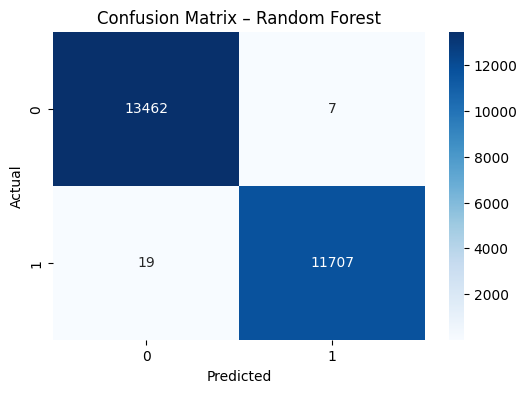

In [9]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title(f"Confusion Matrix – {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

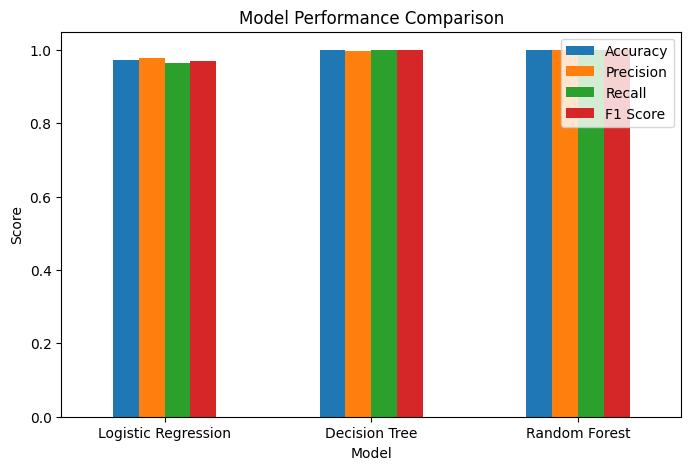

In [10]:
results_df.set_index("Model").plot(kind='bar', figsize=(8,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

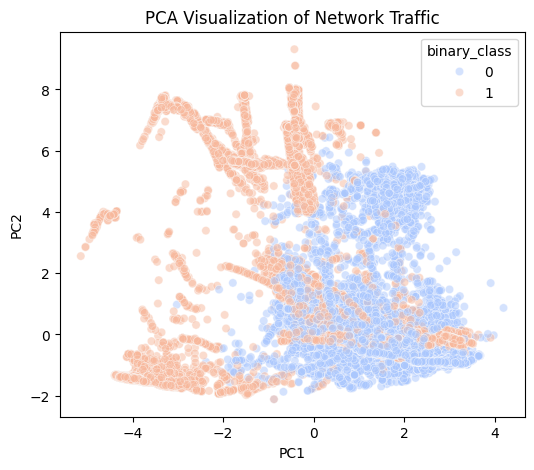

In [11]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_processed)

plt.figure(figsize=(6,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y_train,
    palette='coolwarm',
    alpha=0.5
)

plt.title("PCA Visualization of Network Traffic")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

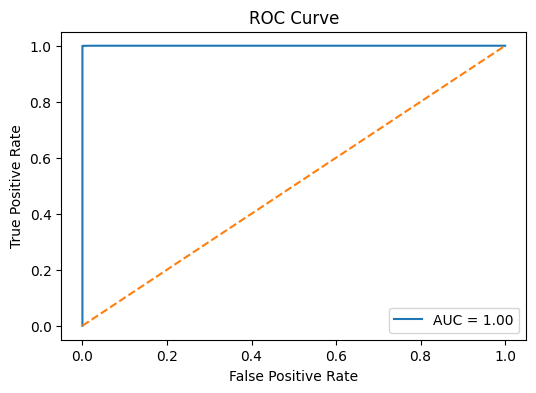

In [12]:
from sklearn.metrics import roc_curve, auc

# Use Random Forest (or best model)
model = models[best_model_name]

y_probs = model.predict_proba(X_test_processed)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

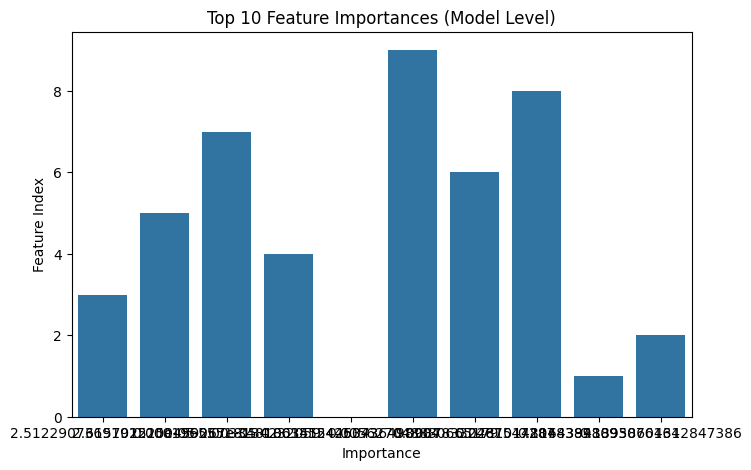

In [13]:
if best_model_name == "Random Forest":
    importances = model.feature_importances_

    plt.figure(figsize=(8,5))
    sns.barplot(x=importances[:10], y=np.arange(10))

    plt.title("Top 10 Feature Importances (Model Level)")
    plt.xlabel("Importance")
    plt.ylabel("Feature Index")

    plt.show()

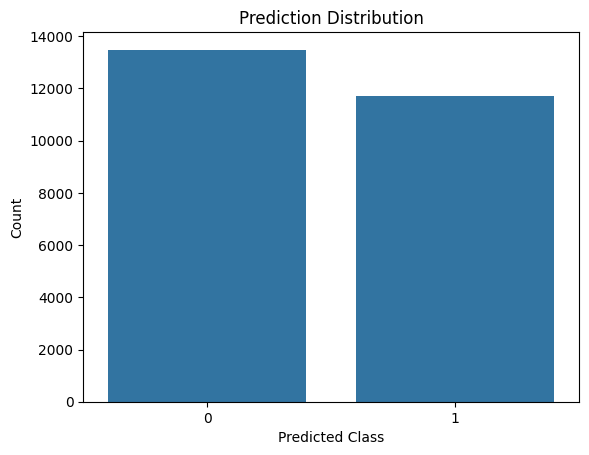

In [14]:
sns.countplot(x=best_pred)

plt.title("Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")

plt.show()

In [15]:
errors = (y_test != best_pred).sum()

print("Total Misclassified Samples:", errors)

Total Misclassified Samples: 26


In [16]:
error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": best_pred
})

error_df[error_df["Actual"] != error_df["Predicted"]].head()

,Actual,Predicted
66013,1,0
51170,1,0
1143,1,0
26872,1,0
21323,0,1


In [17]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    models[best_model_name],
    X_train_processed,
    y_train,
    cv=3,
    scoring='f1'
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean F1:", cv_scores.mean())

Cross-validation F1 scores: [0.99827189 0.99820708 0.99823882]
Mean F1: 0.998239262637199


In [20]:
import joblib

preprocessor = joblib.load("models/preprocessor.pkl")
print(" Preprocessor loaded")

 Preprocessor loaded


In [22]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

joblib.dump(pipeline, "final_pipeline.pkl")

print("DONE")

DONE


## Conclusion

- Multiple machine learning models were trained and evaluated for intrusion detection.
- Random Forest performed the best due to its ability to capture complex patterns in network traffic.
- Recall is a critical metric in this problem, as detecting attacks is more important than minimizing false alarms.
- Feature engineering from Week 3 improved model performance by reducing noise and focusing on important features.
- Overall, the model is able to effectively distinguish between normal and malicious network activity.